In [46]:
import torch
import torch.distributions as dist
import neml2
from pyzag import nonlinear, reparametrization, chunktime
from collections import defaultdict
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import os
import re
import tqdm
import pandas as pd
import copy
from scipy.stats import qmc
from scipy.optimize import brentq
from neml2.cli.inspect import main as inspect_main
import math

In [47]:
torch.manual_seed(0)

torch.set_default_dtype(torch.double)
if torch.cuda.is_available():
    dev = "cuda:0"
    print("CUDA is available")
    print(f"CUDA version: {torch.version.cuda}")
else:
    dev = "cpu"
device = torch.device(dev)

CUDA is available
CUDA version: 13.0


In [48]:
class SolveStrain(torch.nn.Module):
    """Just integrate the model through some strain history

    Args:
        discrete_equations: the pyzag wrapped model
        nchunk (int): number of vectorized time steps
        rtol (float): relative tolerance to use for Newton's method during time integration
        atol (float): absolute tolerance to use for Newton's method during time integration
    """

    def __init__(self, discrete_equations, nchunk=1, rtol=1.0e-6, atol=1.0e-4, initial_rho_m=4.51):
        super().__init__()
        self.discrete_equations = discrete_equations
        self.nchunk = nchunk
        self.cached_solution = None
        self.rtol = rtol
        self.atol = atol
        self.initial_rho_m = initial_rho_m

    def forward(self, time, temperature, loading, cache=False):
        """Integrate through some time/temperature/strain history and return stress
        Args:
            time (torch.tensor): batched times
            temperature (torch.tensor): batched temperatures
            loading (torch.tensor): loading conditions, which are the input strain in the first base index and then the stress (zero) in the remainder

        Keyword Args:
            cache (bool): if true, cache the solution and use it as a predictor for the next call.
                This heuristic can speed things up during inference where the model is called repeatedly with similar parameter values.
        """
        if cache and self.cached_solution is not None:
            solver = nonlinear.RecursiveNonlinearEquationSolver(
                self.discrete_equations,
                step_generator=nonlinear.StepGenerator(self.nchunk),
                predictor=nonlinear.FullTrajectoryPredictor(self.cached_solution),  # type: ignore
                nonlinear_solver=chunktime.ChunkNewtonRaphson(
                    rtol=self.rtol, atol=self.atol, throw_on_fail=True
                ),
            )
        else:
            solver = nonlinear.RecursiveNonlinearEquationSolver(
                self.discrete_equations,
                step_generator=nonlinear.StepGenerator(self.nchunk),
                predictor=nonlinear.PreviousStepsPredictor(),  # type: ignore
                nonlinear_solver=chunktime.ChunkNewtonRaphson(
                    rtol=self.rtol, atol=self.atol, throw_on_fail=True
                ),
            )

        control = torch.zeros_like(loading)
        control[..., 1:] = 1.0

        # Pack the per-force raw tensors into the single flat forces tensor
        # pyzag consumes. ``assemble_forces`` uses the adapter's own force
        # layout, so the packing is guaranteed to match how the factory later
        # splits the tensor back apart (``_split_by_layout``); base sizes come
        # from the layout, so scalars need no trailing-1 unsqueeze here.
        forces = self.discrete_equations.assemble_forces(
            {
                "t": time,
                "temperature": temperature,
                "fixed_values": loading,
                "control": control,
            }
        )
        state0 = self.discrete_equations.assemble_state(
            {
                "mixed_state": torch.zeros(forces.shape[1:-1] + (6,), device=forces.device),
                "log_rho_m": torch.full(
                    forces.shape[1:-1], math.log(self.initial_rho_m), device=forces.device
                ),
                "back_stress": torch.zeros(forces.shape[1:-1] + (6,), device=forces.device),
                "equivalent_plastic_strain": torch.zeros(forces.shape[1:-1], device=forces.device),
            }
        )

        result = nonlinear.solve_adjoint(solver, state0, len(forces), forces)

        if cache:
            self.cached_solution = result.detach().clone()

        if not torch.isfinite(result).all():
            raise RuntimeError(
                "Non-finite state in the integrated solution: the solve produced NaN/Inf "
                "that pyzag's convergence test did not catch. Reduce nchunk or the step size."
            )

        return result[..., 0:1]

    def density(self, result):
        """Physical mobile dislocation density (um^{-2}) from a solved trajectory."""
        return torch.exp(result[..., 6:7])

In [4]:
nmodel = neml2.load_nonlinear_system("tungsten.i", "eq_sys")
nmodel.to(device=device)
pmodel = neml2.pyzag.NEML2PyzagModel(nmodel)
neml2.compile(pmodel)

model = SolveStrain(pmodel)
_ = inspect_main(["tungsten.i", "implicit_rate"])

Model: ComposedModel

Inputs (15):
  log_rho_m: type=Scalar
  control: type=SR2
  fixed_values: type=SR2
  mixed_state: type=SR2
  control~1: type=SR2
  fixed_values~1: type=SR2
  mixed_state~1: type=SR2
  t: type=Scalar
  t~1: type=Scalar
  back_stress: type=SR2
  temperature: type=Scalar
  back_stress~1: type=SR2
  equivalent_plastic_strain: type=Scalar
  equivalent_plastic_strain~1: type=Scalar
  log_rho_m~1: type=Scalar

Outputs (4):
  back_stress_residual: type=SR2
  equivalent_plastic_strain_residual: type=Scalar
  log_rho_m_residual: type=Scalar
  stress_residual: type=SR2

Parameters (43):
  rho_m_from_log.scaling: dtype=torch.float64, device=cpu, shape=[]
  rho_m_from_log.rate: dtype=torch.float64, device=cpu, shape=[]
  L.c_lath: dtype=torch.float64, device=cpu, shape=[]
  L.d_lath: dtype=torch.float64, device=cpu, shape=[]
  L.c_block: dtype=torch.float64, device=cpu, shape=[]
  L.d_block: dtype=torch.float64, device=cpu, shape=[]
  L.c_packet: dtype=torch.float64, device=cp

In [5]:
nrates = 3
ntemps = 50
nbatch = nrates * ntemps
max_strain = 0.025
ntime = 200

temps = torch.linspace(300, 900, 50, device=device)
rates = torch.tensor([6.4e-2, 6.4e-3, 6.4e-4], device=device)
conditions = torch.cartesian_prod(temps, rates)

times = torch.zeros((ntime, nbatch, 1), device=device)
temperature = torch.zeros((ntime, nbatch, 1), device=device)
loading = torch.zeros((ntime, nbatch, 6), device=device)

for i, (T, rate) in enumerate(conditions):
    loading[:, i, 0] = torch.linspace(0, max_strain, ntime, device=device)
    times[:, i, 0] = torch.linspace(0, max_strain / rate, ntime, device=device)
    temperature[:, i, 0] = T

print(
    f"\n--- Full Input Tensors ---\ntime: {times.shape}\ntemperature: {temperature.shape}\nloading: {loading.shape}"
)


--- Full Input Tensors ---
time: torch.Size([200, 150, 1])
temperature: torch.Size([200, 150, 1])
loading: torch.Size([200, 150, 6])


==================== Available Parameters ====================
discrete_equations.rho_m_from_log_scaling: Parameter containing:
tensor(1., device='cuda:0', requires_grad=True)

discrete_equations.rho_m_from_log_rate: Parameter containing:
tensor(1., device='cuda:0', requires_grad=True)

discrete_equations.L_c_lath: Parameter containing:
tensor(1., device='cuda:0', requires_grad=True)

discrete_equations.L_d_lath: Parameter containing:
tensor(0.5000, device='cuda:0', requires_grad=True)

discrete_equations.L_c_block: Parameter containing:
tensor(0., device='cuda:0', requires_grad=True)

discrete_equations.L_d_block: Parameter containing:
tensor(1., device='cuda:0', requires_grad=True)

discrete_equations.L_c_packet: Parameter containing:
tensor(0., device='cuda:0', requires_grad=True)

discrete_equations.L_d_packet: Parameter containing:
tensor(1., device='cuda:0', requires_grad=True)

discrete_equations.L_c_PAG: Parameter containing:
tensor(0., device='cuda:0', requires_grad=True)

dis

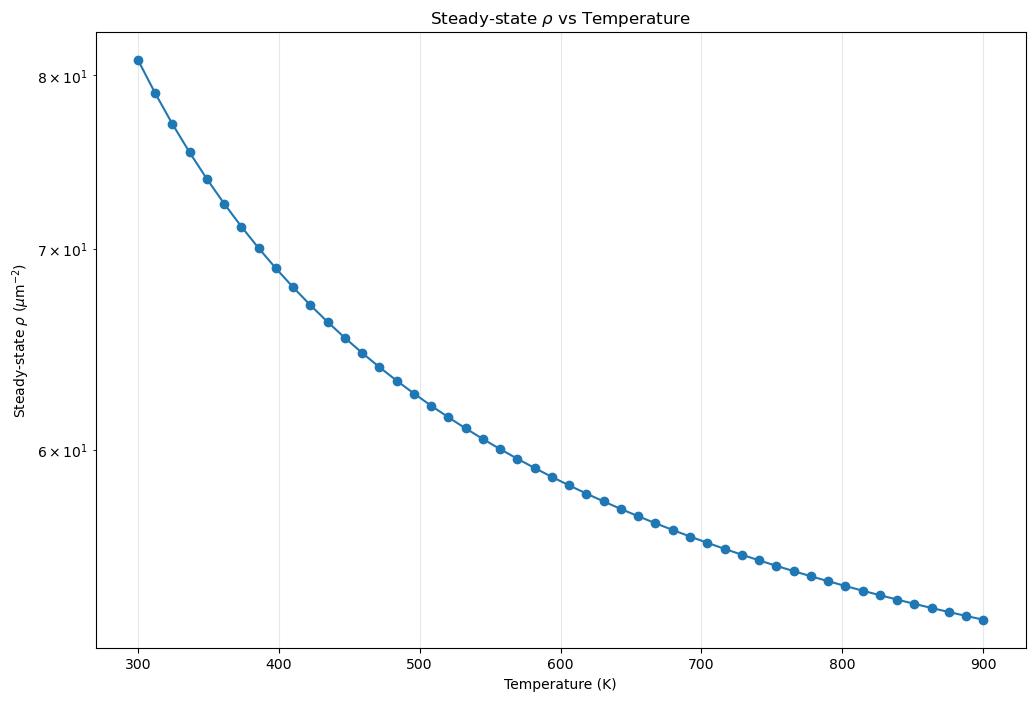

In [11]:
print(20 * "=" + " Available Parameters " + 20 * "=")
for n, p in model.named_parameters():
    print(f"{n}: {p}\n")

nmodel_inner = neml2.load_model("tungsten.i", "implicit_rate")

print(20 * "=" + " Available Buffers " + 20 * "=")
for n, b in nmodel_inner.named_buffers():
    print(f"{n}: {b}")

k1 = model.get_parameter("discrete_equations.rho_m_rate_k1").data.item()
k2_0 = model.get_parameter("discrete_equations.rho_m_rate_k2_0").data.item()
Q_d = model.get_parameter("discrete_equations.rho_m_rate_Q_d").data.item()
c_lath = model.get_parameter("discrete_equations.L_c_lath").data.item()
d_lath = model.get_parameter("discrete_equations.L_d_lath").data.item()
k_B = nmodel_inner.get_buffer("v_disl.k_B").data.item()
rho_m = model.initial_rho_m
lambda_micro = c_lath / d_lath


def rho_ss(T):
    k2 = k2_0 * np.exp(-Q_d / (k_B * T))
    sqrt_rho_ss = (k1 + np.sqrt(k1**2 + 4.0 * k1 * k2 * lambda_micro)) / (2.0 * k2)
    return sqrt_rho_ss * sqrt_rho_ss


rho_dict = {float(T): float(rho_ss(float(T))) for T in temps}

plt.figure(figsize=(12, 8))
plt.plot(temps.detach().cpu().numpy(), [rho_dict[float(T)] for T in temps], "o-")
plt.title(r"Steady-state $\rho$ vs Temperature")
plt.xlabel("Temperature (K)")
plt.ylabel(r"Steady-state $\rho$ ($\mu$m$^{-2}$)")
plt.yscale("log")
plt.grid(alpha=0.3)

In [12]:
with torch.no_grad():
    flow_stress = model(times, temperature, loading)
    print(flow_stress)
    print(flow_stress.shape)

/tmp/ipykernel_47690/2516360069.py:41: UserWarning: pyzag lowered torch._functorch.config.donated_buffer's default to False process-wide. AOTAutograd 'donated buffers' (torch>=2.12) are incompatible with pyzag's retain_graph=True adjoint over torch.compile'd models, which otherwise raises 'compiled with non-empty donated buffers'. To keep donated buffers enabled, restore torch._functorch.config._config['donated_buffer'].default = True -- compiled models differentiated through the adjoint will then error.
  solver = nonlinear.RecursiveNonlinearEquationSolver(


tensor([[[  0.0000],
         [  0.0000],
         [  0.0000],
         ...,
         [  0.0000],
         [  0.0000],
         [  0.0000]],

        [[ 51.5075],
         [ 51.5075],
         [ 51.5075],
         ...,
         [ 49.7833],
         [ 46.7249],
         [ 45.4205]],

        [[103.0151],
         [103.0151],
         [103.0151],
         ...,
         [ 77.0074],
         [ 62.5487],
         [ 58.5421]],

        ...,

        [[945.2510],
         [832.0504],
         [728.7886],
         ...,
         [107.7479],
         [ 95.9540],
         [ 93.6447]],

        [[945.2510],
         [832.0504],
         [728.7886],
         ...,
         [107.7479],
         [ 95.9540],
         [ 93.6447]],

        [[945.2510],
         [832.0504],
         [728.7886],
         ...,
         [107.7479],
         [ 95.9540],
         [ 93.6447]]], device='cuda:0')
torch.Size([200, 150, 1])


In [13]:
# ============================================================
# Constants
# ============================================================
kB = 1.380649e-23  # J / K
eV_to_J = 1.602176634e-19  # J / eV
kB_eV = 8.617333262e-5  # eV / K

# ==========================
# Tungsten Lattice Constants
# ==========================
a = 3.16e-4  # microns
b = np.sqrt(3) / 2 * a  # microns
h = np.sqrt(2 / 3) * a  # microns
w = 25 * a  # microns

# ==========================
# Screw Velocity Parameters
# ==========================
Bk = 8.3e-11  # MPa*s
tau_p = 950  # MPa
H_0 = 4.08555042e-19  # J
p = 0.6
q = 1.4
T_0 = 3325.5  # K
m_exp = 0.33

# Keep this analytical root solve entirely in NumPy/scipy space.
rho_temperature_grid = np.array(sorted(rho_dict), dtype=float)
rho_value_grid = np.array([rho_dict[T] for T in rho_temperature_grid])


def G_of_T(T_val):
    Ea = -2.716e-2
    Eb = 0.01253e3
    Ec = 396.507e3
    nua = 3.157e-9
    nub = -8.030e-6
    nuc = 0.285
    E_T = Ea * T_val**2 + Eb * T_val + Ec
    nu_T = nua * T_val**2 + nub * T_val + nuc
    return E_T / (2 * (1 + nu_T))


def rho_of_T(T_val):
    return np.interp(
        np.asarray(T_val, dtype=float),
        rho_temperature_grid,
        rho_value_grid,
    )


def tau_a_of_T(T_val):
    alpha_a = 0.23
    lambda_micro_a = 1 / 0.5
    return m_exp * alpha_a * G_of_T(T_val) * b * (np.sqrt(rho_of_T(T_val)) + lambda_micro_a)


def screw_velocity(tau_eff_val, T_val):
    K = 2 * h * b / (w * Bk)
    tau_1 = tau_eff_val - tau_a_of_T(T_val)
    mcl_tau_1 = np.maximum(tau_1, 0)
    tau_ratio = tau_1 / tau_p
    tau_ratio = np.clip(tau_ratio, 1e-30, 1.0 - 1e-6)
    dg = (1.0 - tau_ratio**p) ** q - T_val / T_0
    dg1 = np.maximum(dg, 0.0)
    exp_coeff = np.exp(-H_0 * dg1 / (2.0 * kB * T_val))
    return K * mcl_tau_1 * exp_coeff


def gamma_dot(tau_eff_val, T_val):
    return rho_of_T(T_val) * b * screw_velocity(tau_eff_val, T_val)


def solve_tau_for_g_dot(gamma_dot_target, T_val):
    gamma_dot_target = float(gamma_dot_target)
    T_val = float(T_val)
    tau_a_T = tau_a_of_T(T_val)
    tau_min = tau_a_T + 1e-6
    tau_max = tau_a_T + 0.999 * tau_p

    f_min = gamma_dot(tau_min, T_val) - gamma_dot_target
    f_max = gamma_dot(tau_max, T_val) - gamma_dot_target

    if not np.isfinite(f_min) or not np.isfinite(f_max) or f_min * f_max > 0:
        return np.nan

    return brentq(
        lambda tau: gamma_dot(tau, T_val) - gamma_dot_target,
        tau_min,
        tau_max,
        xtol=1e-12,
        rtol=1e-10,
        maxiter=500,
    )

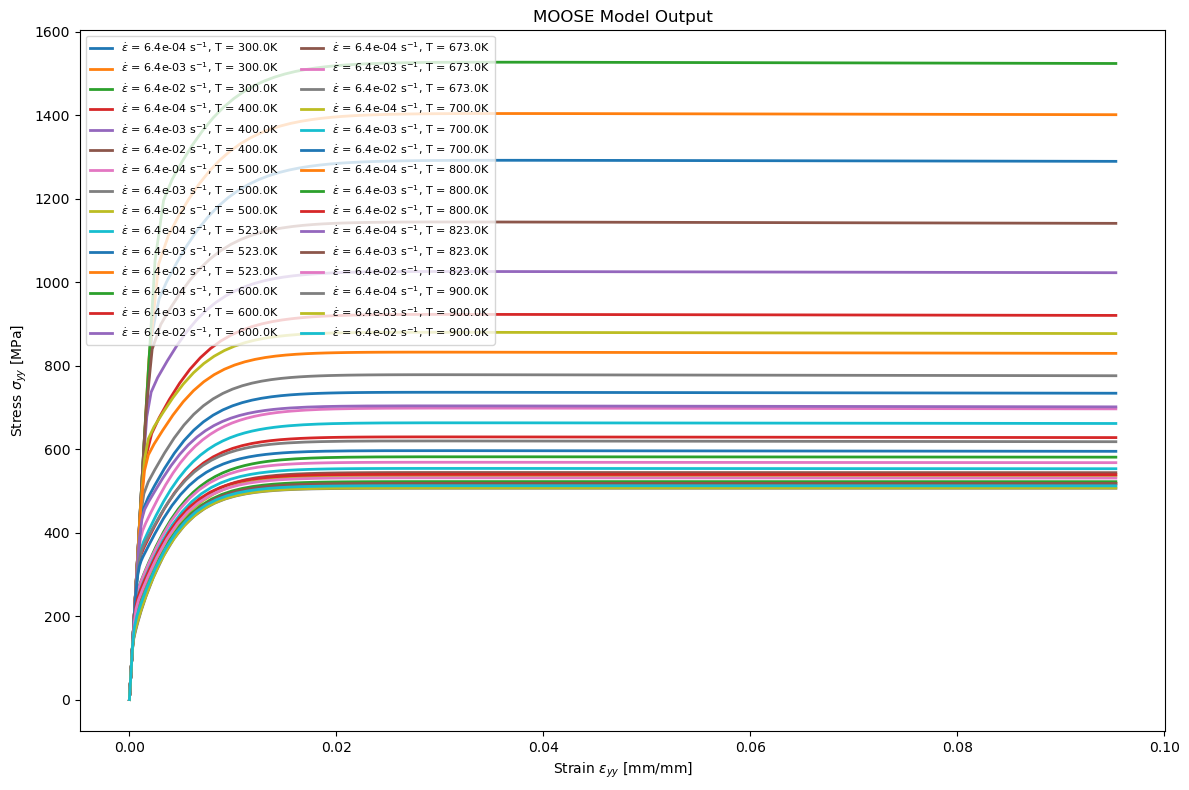

In [50]:
path = "MOOSE_validation_data"

files = [f for f in sorted(os.listdir(path)) if f.startswith("W") and f.endswith(".csv")]
pattern = re.compile(r"_T(?P<T>[\d.]+)K_rate(?P<rate>[\d.eE+-]+)\.csv$")

frames = []
for f in files:
    m = pattern.search(f)
    if m is None:
        raise ValueError(f"filename {f!r} does not match expected pattern")
    df = pd.read_csv(os.path.join(path, f))
    df["T"] = float(m.group("T"))  # from the filename -> the t=0 row keeps its group
    df["rate"] = float(m.group("rate"))
    frames.append(df)
MOOSE_data = pd.concat(frames, ignore_index=True)

by_both = dict(tuple(MOOSE_data.groupby(["T", "rate"])))
temps, rates = sorted(MOOSE_data["T"].unique()), sorted(MOOSE_data["rate"].unique())

fig, ax = plt.subplots(figsize=(12, 8))
for T in temps:
    for r in rates:
        c = by_both[(T, r)].sort_values("strain_yy")
        ax.plot(
            c["strain_yy"],
            c["stress_yy"],
            lw=2,
            label=rf"$\dot{{\epsilon}}$ = {r:.1e} s$^{{-1}}$, T = {T}K",
        )

ax.set_title("MOOSE Model Output")
ax.legend(fontsize=8, ncol=2)
ax.set_xlabel("Strain $\\epsilon_{yy}$ [mm/mm]")
ax.set_ylabel("Stress $\\sigma_{yy}$ [MPa]")
fig.tight_layout()

NEML2 vs analytical tau_eff RMSE: 3.33132 MPa


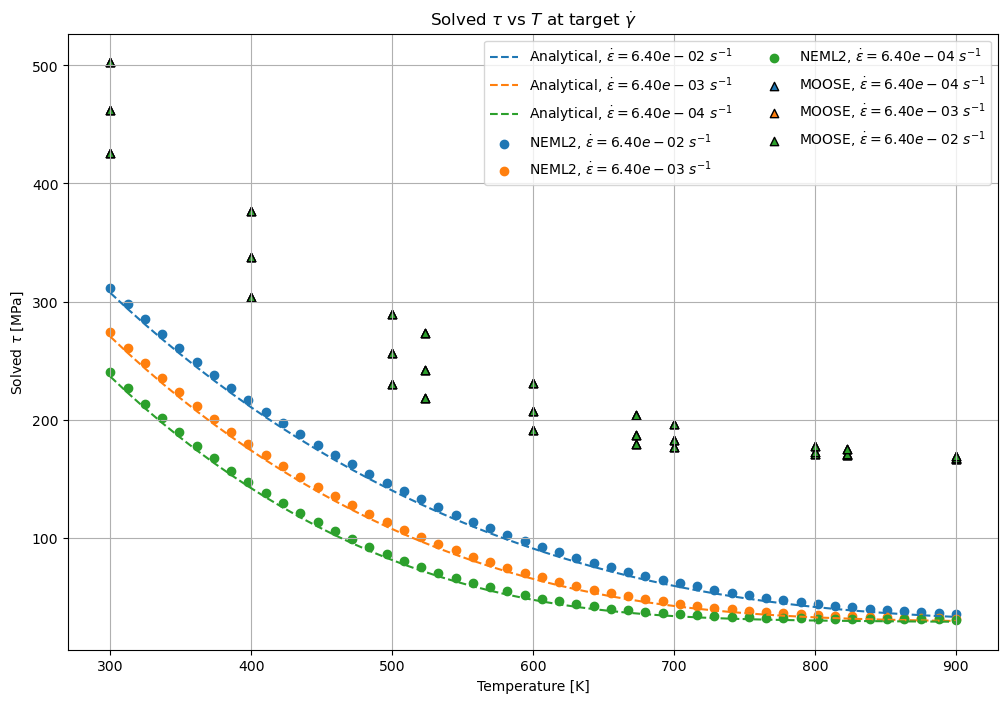

In [52]:
# ============================================================
# Analytical Calculation vs. NEML2 Output
# ============================================================
erate = np.array([6.4e-2, 6.4e-3, 6.4e-4])
T_sweep = np.linspace(300.0, 900.0, 50)

# NEML2 reports tau_eff = m * sigma, so compare both models in tau_eff.
flow_stress_final = flow_stress[-10:, ...].mean(dim=0)
batch_temps = conditions[:, 0]
batch_rates = conditions[:, 1]
m = nmodel_inner.get_buffer("v_disl.m").data.item()
tau_eff = m * flow_stress_final

batch_temperature_np = batch_temps.detach().cpu().numpy().reshape(-1)
batch_rate_np = batch_rates.detach().cpu().numpy().reshape(-1)
neml2_tau_eff_np = tau_eff.detach().cpu().numpy().reshape(-1)

fig, ax = plt.subplots(figsize=(12, 8))
for i, target_rate in enumerate(erate):
    target_gdot = target_rate / m
    tau_solutions = np.array([solve_tau_for_g_dot(target_gdot, T_val) for T_val in T_sweep])
    ax.plot(
        T_sweep,
        tau_solutions,
        "--",
        color=f"C{i}",
        label=rf"Analytical, $\dot{{\epsilon}}={target_rate:.2e}$ $s^{{-1}}$",
    )

for i, target_rate in enumerate(erate):
    rate_mask = np.isclose(batch_rate_np, target_rate, rtol=1e-6, atol=1e-12)
    ax.scatter(
        batch_temperature_np[rate_mask],
        neml2_tau_eff_np[rate_mask],
        color=f"C{i}",
        marker="o",
        label=rf"NEML2, $\dot{{\epsilon}}={target_rate:.2e}$ $s^{{-1}}$",
    )

# MOOSE model output
MOOSE_tau_eff_list = []
MOOSE_temps_list = []
for T in temps:
    for r in rates:
        c = by_both[(T, r)].sort_values("strain_yy")
        MOOSE_flow_stress = c["stress_yy"].iloc[-1]
        MOOSE_tau_eff = m_exp * MOOSE_flow_stress
        MOOSE_tau_eff_list.append(MOOSE_tau_eff)
        MOOSE_temps_list.append(T)

for i, r in enumerate(rates):
    ax.scatter(
        MOOSE_temps_list,
        MOOSE_tau_eff_list,
        color=f"C{i}",
        marker="^",
        edgecolors="k",
        label=rf"MOOSE, $\dot{{\epsilon}}={r:.2e}$ $s^{{-1}}$",
    )

# Evaluate the analytical solution at the exact NEML2 temperatures for a numerical comparison.
analytical_tau_at_neml2 = np.array(
    [
        solve_tau_for_g_dot(rate / m, temperature_value)
        for rate, temperature_value in zip(batch_rate_np, batch_temperature_np)
    ]
)
valid = np.isfinite(analytical_tau_at_neml2) & np.isfinite(neml2_tau_eff_np)
if np.any(valid):
    rmse = np.sqrt(np.mean((analytical_tau_at_neml2[valid] - neml2_tau_eff_np[valid]) ** 2))
    print(f"NEML2 vs analytical tau_eff RMSE: {rmse:.6g} MPa")

ax.set_xlabel("Temperature [K]")
ax.set_ylabel(r"Solved $\tau$ [MPa]")
ax.set_title(r"Solved $\tau$ vs $T$ at target $\dot{\gamma}$")
ax.grid(True)
ax.legend(ncol=2)
plt.show()